<h1 align="center">AtliQo Bank Credit Card Launch: Phase 1</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

<h1 style="color:purple" align="center">Data Import<h1>

### Option 1. Read data from CSV

In [2]:
df_cust = pd.read_csv('customers.csv')
df_cs = pd.read_csv('credit_profiles.csv')
df_trans = pd.read_csv('transactions.csv')

### Option 2. Read it from MySQL

In [3]:
# import mysql.connector

# conn = mysql.connector.connect(
#     host='localhost',
#     user='root',
#     passwd='root',
#     database='e_master_card'
# )

# df_cust = pd.read_sql("SELECT * FROM customers", conn)
# df_cust.head(3)

In [4]:
# df_trans=pd.read_sql("SELECT * FROM transactions",conn)
# df_trans.head()

In [5]:
# df_cs = pd.read_sql("SELECT * FROM credit_profiles", conn)
# df_cs.head(3)

In [6]:
# # when you are done importing the data, close the connection
# conn.close()

<h1 style="color:purple" align="center">Explore Customers Table<h1>

In [7]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


In [8]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [9]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [10]:
df_trans.shape

(500000, 7)

<h2 style="color:Blue">1. Analyze Income Column<h2>

### 7.4: Data Cleaning:Handling Null Values(Annual Income)

In [11]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [12]:
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [13]:
df_cust[df_cust.annual_income.isna()]


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,NaN,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,NaN,Single
97,98,Virat Puri,Male,47,Suburb,Business Owner,NaN,Married
102,103,Aarav Shah,Male,32,City,Data Scientist,NaN,Married
155,156,Kiaan Saxena,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Verma,Male,52,City,Business Owner,NaN,Single
186,187,Samar Sardar,Male,53,City,Consultant,NaN,Single
192,193,Ishan Joshi,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Advait Mukherjee,Male,48,City,Business Owner,NaN,Married
232,233,Aditya Goel,Male,26,City,Freelancer,NaN,Married


We can handle these null values using different ways,

1. **Remove them**: Since there are 50 of them in a dataframe of 1000, we will not remove them as we don't want to loose some important records
1. **Replace them with mean or median**: It is suggested with use median in the case of income. This is because in an income data there could be outliers and median is more robust to these outliers
1. **Replace them with median per occupation**: Occupation wise median income can vary. It is best to use a median per occupation for replacement

In [14]:
df_cust.annual_income.median()

np.float64(112218.5)

### Occupation wise median

In [15]:
Occupation_wise_median=df_cust.groupby('occupation')['annual_income'].median()
Occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [16]:
# 2. Replace null values in annual_income with the median income of their occupation group
df_cust['annual_income'] = df_cust.apply(
    lambda row: Occupation_wise_median[row['occupation']] if pd.isnull(row['annual_income']) else row['annual_income'],
    axis=1
)

#Occupation_wise_median[row['occupation']] ka matlab:

#Row ka occupation check karo, aur us occupation ka median income lo.

Previously records at location 14 and  82 had null annual income. Now you have a median value per occupation

In [17]:
df_cust.iloc[[14,83]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,45794.0,Married
83,84,Advik Sethi,Male,43,Rural,Consultant,15804.0,Married


In [18]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

Awesome 😀 Number of null values in all the columns is zero now! Hurray 🥳

Now that there are no null values, let us view the distribution of annual income

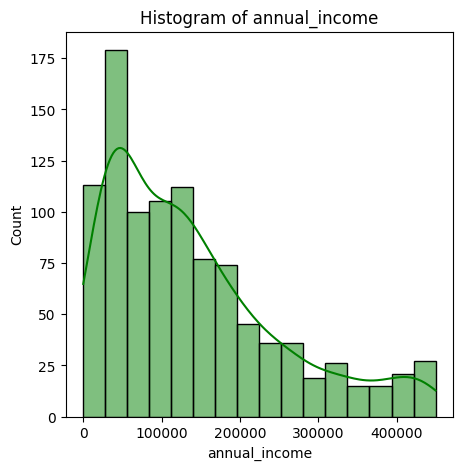

In [19]:
plt.figure(figsize=(5, 5))
sns.histplot(df_cust['annual_income'], kde=True, color='green', label='Data')
plt.title('Histogram of annual_income')
plt.show()

because less bumber of people has higher income

### 7.5: Data Cleaning:Outlier Detection: Annual income

Let us use standard deviation to detect outliers. Common practice is to treat anything that +/- 3 std dev as an outlier

In [20]:
df_cust['annual_income'].mean(),df_cust['annual_income'].std()

(np.float64(138916.7655), np.float64(110969.4086433663))

In [21]:
lower=df_cust['annual_income'].mean()-3* df_cust['annual_income'].std()
Upper=df_cust['annual_income'].mean()+3* df_cust['annual_income'].std()
lower,Upper

(np.float64(-193991.4604300989), np.float64(471824.9914300989))

In [22]:
df_cust[df_cust['annual_income']<lower]|df_cust[df_cust['annual_income']>Upper]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


we see minimum income as 2. We kneow the standard deviation technique but it is better to use pragmatic approach
Our business manager has told us that the income should be at least 100. We can use this as our criteria to find out the outliers on the lower end. These outliers could have occured due to a data error.

In [23]:
df_cust[df_cust['annual_income']<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,50.0,Married
262,263,Vivaan Tandon,Male,53,Suburb,Business Owner,50.0,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,50.0,Married
333,334,Avani Khanna,Female,29,City,Data Scientist,50.0,Married
340,341,Priya Sinha,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Advait Batra,Male,54,City,Consultant,2.0,Married
592,593,Priya Gandhi,Female,32,City,Business Owner,50.0,Married
633,634,Rudra Mehtani,Male,26,City,Data Scientist,2.0,Married
686,687,Vihaan Jaiswal,Male,40,City,Business Owner,2.0,Married
696,697,Ishan Negi,Male,47,City,Consultant,20.0,Married


### Outlier Treatment: Annual income

Above records (with <100$ income) are outliers. We have following options to treat them,

1. **Remove them**: After discussion with business, we decided not to remove them as these are valid customers and we want to include them in our analysis
1. **Replace them with mean or median** : Mean is sensitive to outliers. It is better to use median for income values
1. **Replace them with occupation wise median**: Income level may vary based on occupation. For example median income for data scientist can be different from a median income of a business owner. It is better to use occupation wise median income for replacement

In [24]:
Occupation_wise_median['Artist']

np.float64(45794.0)

In [25]:
for index,row in df_cust.iterrows():
    if row['annual_income']<100:
        occupation=df_cust.at[index,"occupation"]
        df_cust.at[index,"annual_income"]=Occupation_wise_median[occupation]

In [26]:
df_cust[df_cust['annual_income']<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [27]:
df_cust.loc[[31,316]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,261191.5,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,58017.0,Married


In [28]:
Occupation_wise_median['Business Owner']

np.float64(261191.5)

Record at 31 and 316 location had annual income of < 100$. Now you can see it is replaced by a median income per occupation

### 7.6: Data Visualization:Annual_Income

In [29]:
Occupation_wise_mean=df_cust.groupby('occupation')['annual_income'].mean()
Occupation_wise_mean

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

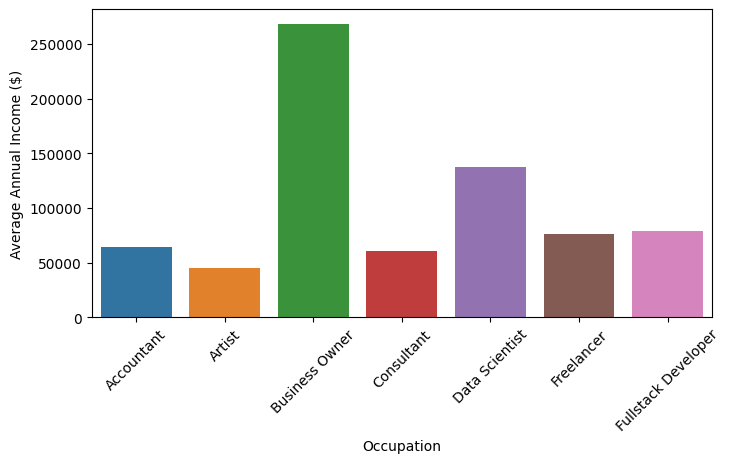

In [30]:
plt.figure(figsize=(8,4))
sns.barplot(x=Occupation_wise_mean.index,y=Occupation_wise_mean.values,palette='tab10')
plt.xticks(rotation=45)
plt.xlabel('Occupation')
plt.ylabel('Average Annual Income ($)')
plt.show()


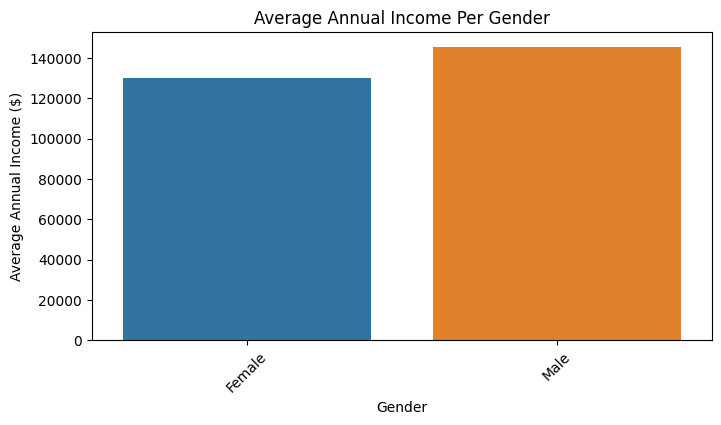

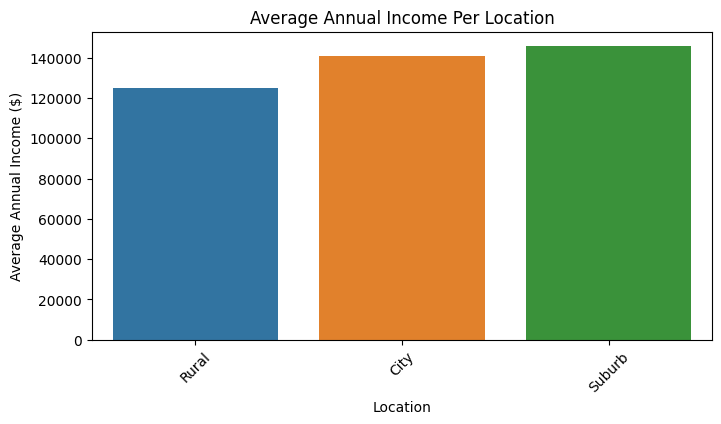

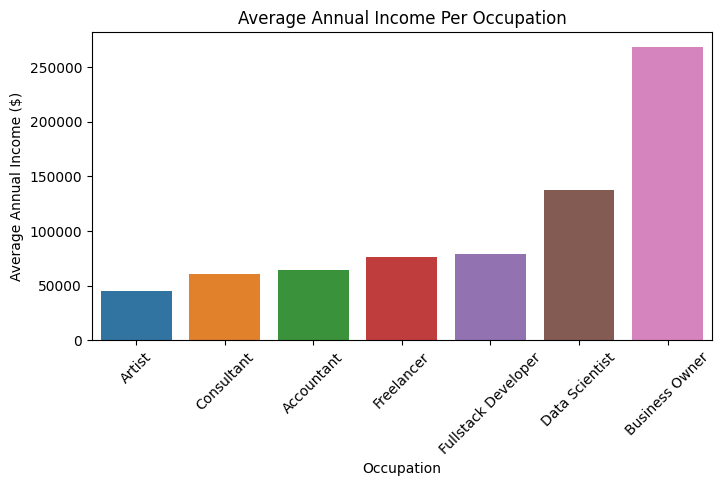

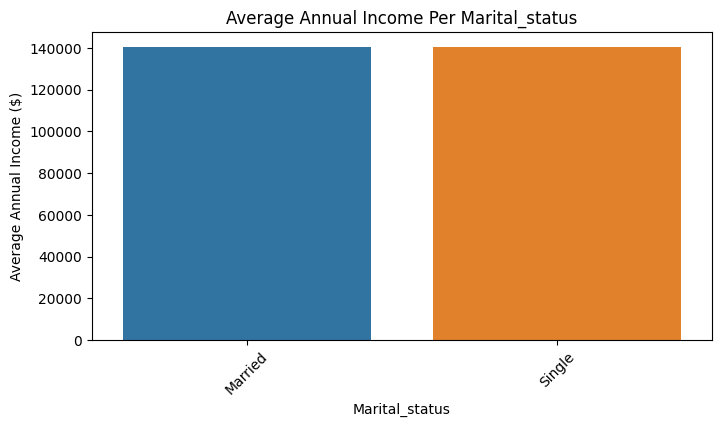

In [31]:
# List of categorical columns
categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

# Loop through each categorical column and plot a bar chart of average annual income
for col in categorical_columns:
    plt.figure(figsize=(8,4))
    avg_income_per_group=df_cust.groupby(col)['annual_income'].mean().sort_values()
    sns.barplot(x=avg_income_per_group.index, y=avg_income_per_group.values, palette='tab10')
    plt.xticks(rotation=45)
    plt.title(f'Average Annual Income Per {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Average Annual Income ($)')
    plt.show()

Below code to Dhaval nay bhi Chat gpt say lia h

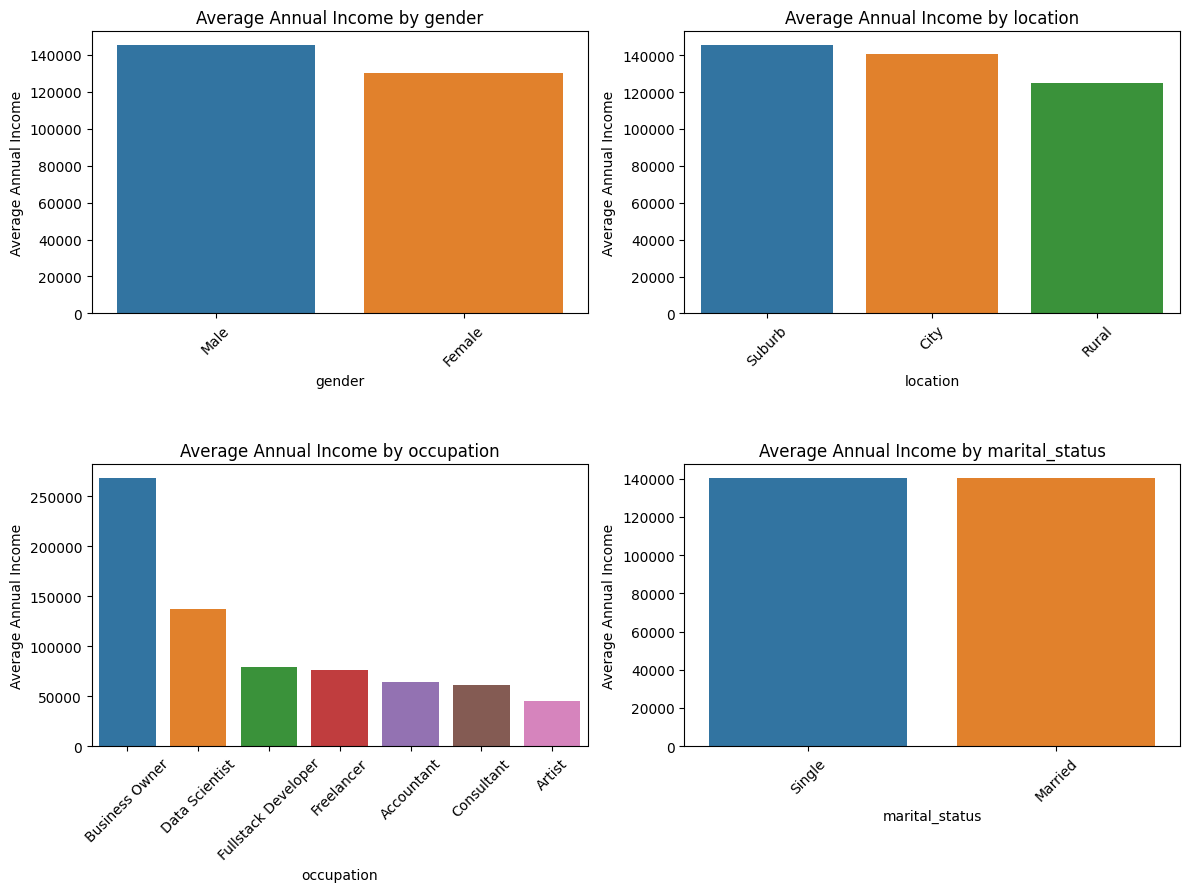

In [32]:
# List of categorical columns
cat_cols = ['gender', 'location', 'occupation', 'marital_status']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_income_by_category = df_cust.groupby(cat_col)['annual_income'].mean().reset_index()
    
    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_income_by_category.sort_values(by='annual_income', ascending=False)
    
    sns.barplot(x=cat_col, y='annual_income', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average Annual Income by {cat_col}')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average Annual Income')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

<h2 style="color:Blue">2. Analyze Age Column<h2>

### 7.7: Exercise: Treat Outliers in Age Column

In our customers’ dataframe, the age column has some outliers. Detect and treat them using an approach that you feel is the best based on your learning in this course. Your business manager has told you that age is valid only if it is between 15 and 80 years.

### Handle Null Values: Age Column by Naima

In [33]:
df_cust[df_cust.age.isna()]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


### No NULL Values in Age Column

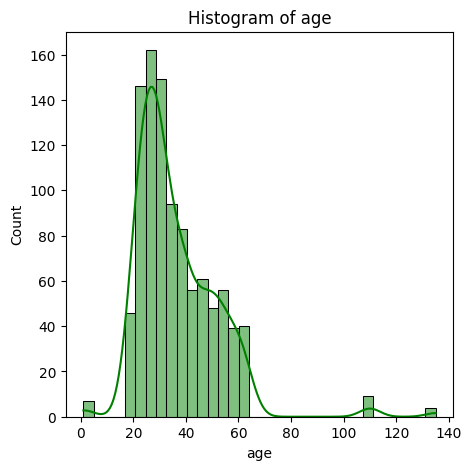

In [34]:
plt.figure(figsize=(5, 5))
sns.histplot(df_cust['age'], kde=True, color='green', label='Data')
plt.title('Histogram of age')
plt.show()

In [35]:
min_age = df_cust.age.min()
max_age = df_cust.age.max()

min_age, max_age

(np.int64(1), np.int64(135))

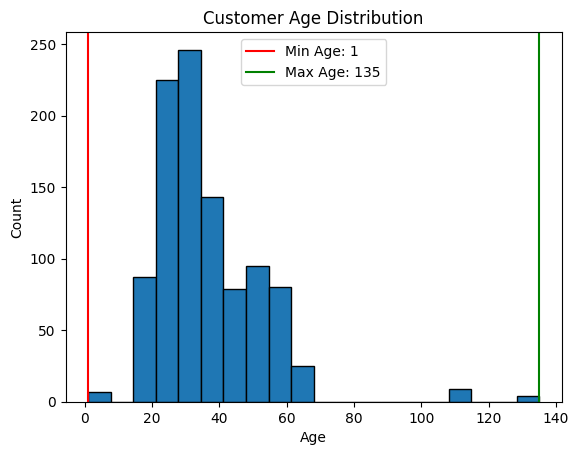

In [36]:
plt.hist(df_cust.age, bins=20, edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Customer Age Distribution")

plt.axvline(min_age, color="red", label=f"Min Age: {min_age}")
plt.axvline(max_age, color="green", label=f"Max Age: {max_age}")

plt.legend()
plt.show()

In [37]:
outliers=df_cust[(df_cust['age']<15 )|( df_cust['age']>80)]
outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
41,42,Aaryan Shah,Male,110,City,Artist,7621.0,Married
165,166,Sia Dutta,Female,1,City,Freelancer,39721.0,Single
174,175,Rohan Sharma,Male,110,City,Freelancer,23723.0,Married
222,223,Arjun Batra,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Aarav Tandon,Male,110,City,Consultant,96522.0,Single
295,296,Ayush Pandey,Male,1,Rural,Accountant,55254.0,Married
325,326,Virat Goel,Male,110,City,Accountant,61021.0,Single
610,611,Rehan Verma,Male,135,Rural,Business Owner,444776.0,Married
692,693,Dhruv Jha,Male,1,City,Business Owner,83045.0,Married


In [38]:
# lower=df_cust['age'].mean()-3* df_cust['age'].std()
# Upper=df_cust['age'].mean()+3* df_cust['age'].std()
# lower,Upper

In [39]:

# df_cust[(df_cust['age'] < lower) | (df_cust['age'] > Upper)]

In [40]:
# gender_wise_median=df_cust.groupby('gender')['age'].median()
# gender_wise_median

In [41]:
# for index, row in df_cust.iterrows():
#     if (row['age'] < 15) or (row['age'] > 80):
#         df_cust.at[index, "age"] = gender_wise_median[row["gender"]]


In [42]:
# # Mask banaye: sirf outliers (<15 ya >80)
# mask = (df_cust['age'] < 15) | (df_cust['age'] > 80)

# # Replace kare gender-wise median se
# df_cust.loc[mask, 'age'] = df_cust.loc[mask, 'gender'].map(gender_wise_median)

In [43]:
# df_cust.loc[[0,41]]

Occupation-wise median

Har occupation ke liye median age assign karega.

Advantage: Credit card targeting me zyaada relevant — “Student”, “Professional”, “Retired” ka median age accurately reflect hota hai.

Outliers replace karne se occupation ka typical age pattern maintain hota hai.

## To mai nay gender wise say replace kar k gaalt kia hia

### Handle Null Values: Age Column by Dhaval

In [44]:
median_age_per_occupation = df_cust.groupby('occupation')['age'].median()
median_age_per_occupation

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [45]:
for index, row in outliers.iterrows():
    df_cust.at[index, 'age'] = median_age_per_occupation[occupation]

In [46]:
df_cust[(df_cust.age<15)|(df_cust.age>80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [47]:
df_cust.age.describe()

count    1000.000000
mean       35.786000
std        12.268934
min        18.000000
25%        26.000000
50%        32.000000
75%        46.000000
max        64.000000
Name: age, dtype: float64

In [48]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


### 7.9: Data Visualization:Age, Gender, Location


#### Creating a new column and new pandas series

In [49]:
# Define the bin edges and labels
bin_edges = [17, 25, 48, 65]  # Adjust as needed
bin_labels = ['18-25', '26-48', '49-65']

# Use the cut function to bin and label the age column
pd.cut(df_cust['age'], bins=bin_edges, labels=bin_labels)

0      26-48
1      26-48
2      18-25
3      18-25
4      26-48
       ...  
995    26-48
996    49-65
997    26-48
998    26-48
999    26-48
Name: age, Length: 1000, dtype: category
Categories (3, object): ['18-25' < '26-48' < '49-65']

In [50]:
# Define the bin edges and labels
bin_edges = [17, 25, 48, 65]  # Adjust as needed
bin_labels = ['18-25', '26-48', '49-65']

# Use the cut function to bin and label the age column
df_cust['age_group'] = pd.cut(df_cust['age'], bins=bin_edges, labels=bin_labels)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married,26-48


## Doing practice step by step to make pie chart

In [51]:
df_cust['age_group'].value_counts(normalize=True)*100

age_group
26-48    57.7
18-25    24.0
49-65    18.3
Name: proportion, dtype: float64

In [52]:
age_group_counts = df_cust['age_group'].value_counts(normalize=True) * 100
type(age_group_counts)

pandas.core.series.Series

In [53]:
age_group_counts.index

CategoricalIndex(['26-48', '18-25', '49-65'], categories=['18-25', '26-48', '49-65'], ordered=True, dtype='category', name='age_group')

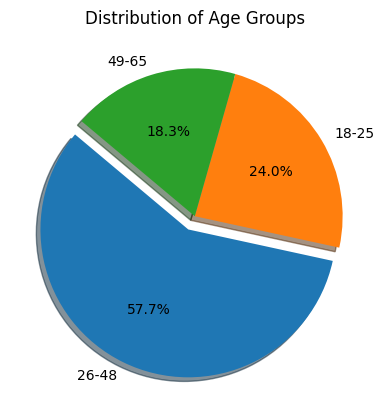

In [54]:
plt.pie(age_group_counts,
        labels=age_group_counts.index,
        autopct='%1.1f%%',
        shadow='True',
        explode=(0.1,0,0),
        startangle=140)
plt.title('Distribution of Age Groups')
 
      

plt.show()

## Summarized Code

In [55]:
# # Calculate the count of values in each age group
# age_group_counts = df_cust['age_group'].value_counts(normalize=True) * 100

# # Plot the pie chart
# plt.figure(figsize=(4, 4))
# plt.pie(
#     age_group_counts, 
#     labels=age_group_counts.index, 
#     explode=(0.1,0,0), 
#     autopct='%1.1f%%', 
#     shadow=True,
#     startangle=140)
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.title('Distribution of Age Groups')
# plt.show()

##### More than 50% of customer base are in in age group of 26 - 48 adn ~26% are of age group 18 - 25

<h2 style="color:Blue">3. Analyze Gender and Location Distribution<h2>

In [56]:
df_cust.location.value_counts()

location
City      683
Suburb    232
Rural      85
Name: count, dtype: int64

In [57]:
df_cust.gender.value_counts()

gender
Male      674
Female    326
Name: count, dtype: int64

In [58]:
a=df_cust.groupby(['location','gender']).size()
a

location  gender
City      Female    226
          Male      457
Rural     Female     26
          Male       59
Suburb    Female     74
          Male      158
dtype: int64

In [59]:
type(a) # series islike an aray but it has multiple indexes

pandas.core.series.Series

In [60]:
customer_location_gender=df_cust.groupby(['location','gender']).size().unstack()
customer_location_gender

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


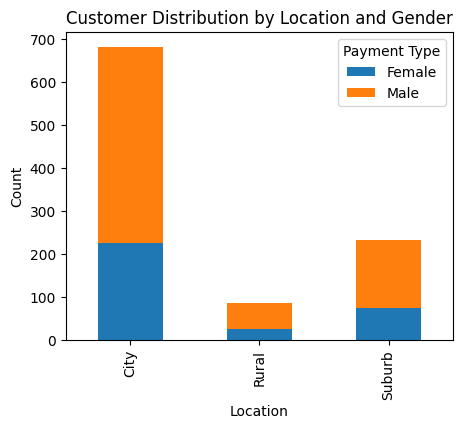

In [61]:
customer_location_gender.plot(kind='bar', stacked=True, figsize=(5, 4))

# Add labels and title
plt.xlabel('Location')
plt.ylabel('Count')

# Show the bar chart
plt.legend(title='Payment Type', bbox_to_anchor=(1, 1))  # Add a legend
plt.title('Customer Distribution by Location and Gender')
plt.show()


### Summarized Code

In [62]:
# customer_location_gender = df_cust.groupby(['location', 'gender']).size().unstack(fill_value=0)

# # Create a stacked bar chart to visualize the distribution of payment types for each occupation
# customer_location_gender.plot(kind='bar', stacked=True, figsize=(5, 4))

# # Add labels and title
# plt.xlabel('Location')
# plt.ylabel('Count')
# plt.title('Customer Distribution by Location and Gender')

# # Show the bar chart
# plt.legend(title='Payment Type', bbox_to_anchor=(1, 1))  # Add a legend

# # Rotate the x-axis labels for better readability
# plt.xticks(rotation=45)

# plt.show()

In [63]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


### Data Cleaning Step 1: Remove Duplicates

In [64]:
df_cs.shape

(1004, 6)

In [65]:
df_cust.shape

(1000, 9)

Hmmm... there are 1004 rows in this dataframe whereas customers dataframe had only 1000. There might be invalid or duplicate data in df_cs

So we have to analyze which extra 4 rows is present in our dataframe

In [66]:
df_cs['cust_id'].nunique() # The count of unique values

1000

In [67]:
df_cs.duplicated('cust_id')

0       False
1       False
2       False
3       False
4       False
        ...  
999     False
1000    False
1001    False
1002    False
1003    False
Length: 1004, dtype: bool

In [68]:
df_cs.duplicated().sum()

np.int64(0)

In [69]:
df_cs[df_cs.duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


Ye poore row ke hisaab se duplicates dhoondhta hai → matlab har column ki value same honi chahiye.
Isiliye yahan empty aa raha tha.

In [70]:
df_cs[df_cs.duplicated('cust_id', keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


Ye sirf cust_id column ke basis par duplicates check karta hai.
Agar ek cust_id multiple rows mein aa raha hai (chahe baaki columns alag-alag ho), woh duplicate count hoga.

In [71]:
df_cs_clean_1=df_cs.drop_duplicates(subset='cust_id',keep='last')
df_cs_clean_1.shape

(1000, 6)

In [72]:
df_cs_clean_1[df_cs_clean_1.duplicated('cust_id', keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


df_cs_clean_1 looks clean now after cleaning duplicates.

Next step would be to see if there are any null values

### Data Cleaning Step 2: Handle Null Values

In [73]:
df_cs_clean_1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

Ahh... look at credit_limit. It has a bunch of null values. we need to clean them up! From the business knowledge we know that credit limit depends on credit score of a customer. We will try to find out if we can figure out a mathematical relationship between credit score and credit limit and use credit score to full NULL values in credit limit. Let's explore a few things here!

A very generic approach is to take mean median mode of credit limit

##### Trying to findout relationship between credit score and credit limit

In [74]:
df_cs_clean_1['credit_limit'].unique()

array([40000.,  1250.,  1000.,   500.,   750.,    nan,  1500., 60000.,
       20000.])

In [75]:
df_cs_clean_1['credit_limit'].value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

Credit limit has only few unique values. Let's check the count for each of these unique values

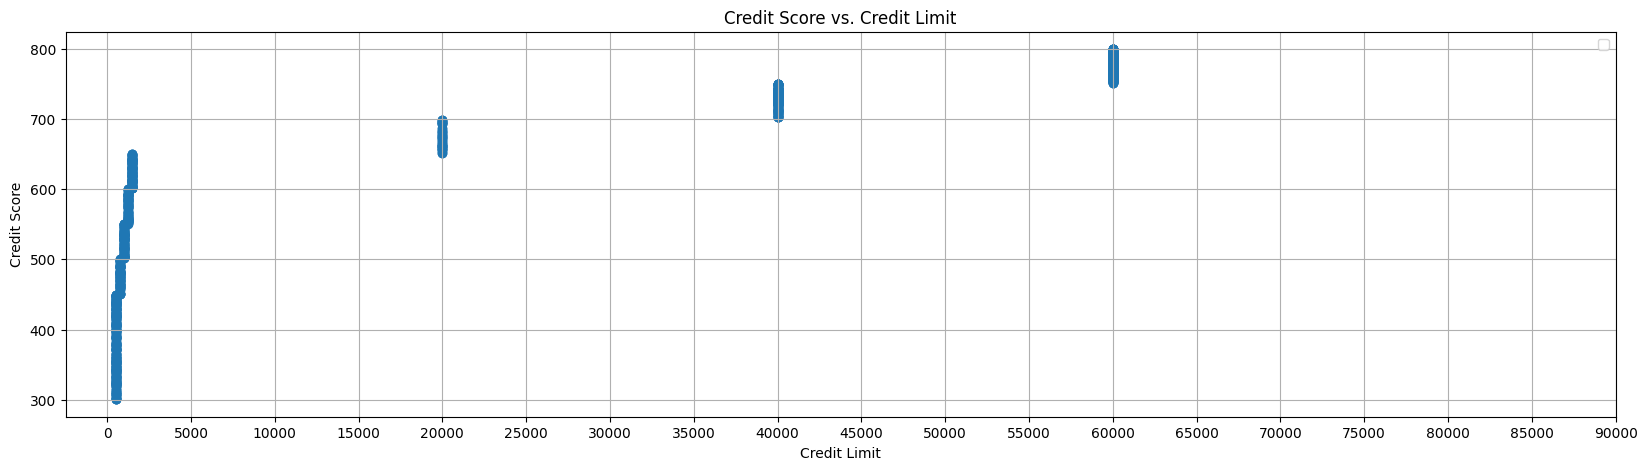

In [76]:
plt.figure(figsize=(20, 5))
plt.scatter(df_cs_clean_1.credit_limit,df_cs_clean_1.credit_score)

# Customize the plot
plt.title('Credit Score vs. Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Credit Score')


# Adjust the y-axis bin interval to 1000
plt.xticks(range(0, 90001, 5000))
plt.grid(True)

# Show the plot
plt.legend()
plt.show()

Here we can see clear relationship between credit score and credit limit. Where there are levels for example, upto 650 score is getting a very minor credit limit (<1000$) where as a score between 650 to 700 is getting around 20000. Score between 700 to 750 is getting around 40K etc.

In [77]:
# Define bin ranges
bin_ranges = [300, 450, 500, 550, 600, 650, 700, 750, 800]

# Create labels for the bins
# You can define credir range manuallybut here we create automatvally(Dhaval take help from ChatGpt)
bin_labels = [f'{start}-{end-1}' for start, end in zip(bin_ranges, bin_ranges[1:])]
bin_labels

['300-449',
 '450-499',
 '500-549',
 '550-599',
 '600-649',
 '650-699',
 '700-749',
 '750-799']

In [78]:
# Use pd.cut to assign data to bins
df_cs_clean_1['credit_score_range'] = pd.cut(df_cs_clean_1['credit_score'], bins=bin_ranges, labels=bin_labels, include_lowest=True, right=False)

In [79]:
df_cs_clean_1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


We can now see a new column called credit_score_range whcih is calculated based on the credit_score column

In [80]:

df_cs_clean_1[df_cs_clean_1['credit_score_range']=="750-799"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
21,22,785,0.897089,36083.0,3.0,60000.0,750-799
25,26,758,0.250811,190838.0,2.0,60000.0,750-799
26,27,766,0.830908,31344.0,3.0,60000.0,750-799
29,30,798,0.222597,7238.0,2.0,60000.0,750-799
31,32,768,0.747793,35109.0,2.0,60000.0,750-799
...,...,...,...,...,...,...,...
988,985,770,0.628088,33405.0,2.0,60000.0,750-799
993,990,772,0.259958,11937.0,2.0,60000.0,750-799
996,993,782,0.477170,20305.0,2.0,60000.0,750-799
1000,997,774,0.465462,17139.0,0.0,60000.0,750-799


In [81]:

df_cs_clean_1[df_cs_clean_1['credit_score_range']=="300-449"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
5,6,442,0.705409,246.0,4.0,500.0,300-449
11,12,429,0.627645,263.0,0.0,500.0,300-449
15,16,347,0.531660,190.0,0.0,500.0,300-449
18,19,447,0.795650,292.0,1.0,500.0,300-449
20,21,381,0.714710,307.0,0.0,500.0,300-449
...,...,...,...,...,...,...,...
981,978,371,0.435307,183.0,2.0,500.0,300-449
982,979,332,0.150815,65.0,1.0,500.0,300-449
984,981,327,0.377202,108.0,3.0,500.0,300-449
989,986,425,0.178470,56.0,4.0,500.0,300-449


Above you can see that for credit score range "750-799" the credit limit is 60K whereas for "300-449" it is 500. We can use MODE function to find out most frequently occuring credit limit for a given score range.

In [82]:
mode_df = df_cs_clean_1.groupby('credit_score_range')['credit_limit'].agg(lambda x: x.mode().iloc[0]).reset_index()
mode_df

,credit_score_range,credit_limit
0,300-449,500.0
1,450-499,750.0
2,500-549,1000.0
3,550-599,1250.0
4,600-649,1500.0
5,650-699,20000.0
6,700-749,40000.0
7,750-799,60000.0


In [83]:
 df_cs_clean_1[ df_cs_clean_1.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
274,275,798,0.491995,19365.0,4.0,NaN,750-799
515,516,555,0.391343,305.0,2.0,NaN,550-599
467,468,354,0.892740,231.0,2.0,NaN,300-449


In [84]:
pd.merge( df_cs_clean_1,mode_df,on="credit_score_range") # yeh credit_limit_x,credit_limit_y is ko sai karo

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit_x,credit_score_range,credit_limit_y
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
...,...,...,...,...,...,...,...,...
995,996,564,0.702963,688.0,2.0,1250.0,550-599,1250.0
996,997,774,0.465462,17139.0,0.0,60000.0,750-799,60000.0
997,998,529,0.585856,386.0,3.0,1000.0,500-549,1000.0
998,999,725,0.249670,6973.0,2.0,40000.0,700-749,40000.0


In [85]:
# Merge the mode values back with the original DataFrame
df_cs_clean_2 = pd.merge(df_cs_clean_1, mode_df, on='credit_score_range', suffixes=('', '_mode'))
df_cs_clean_2.sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
993,994,602,0.605931,796.0,3.0,1500.0,600-649,1500.0
518,519,796,0.424118,19252.0,0.0,60000.0,750-799,60000.0
612,613,470,0.329045,176.0,0.0,750.0,450-499,750.0


In [86]:
 df_cs_clean_2[ df_cs_clean_2.credit_limit.isnull()].sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
515,516,555,0.391343,305.0,2.0,NaN,550-599,1250.0
701,702,769,0.887919,37308.0,4.0,NaN,750-799,60000.0
45,46,761,0.596041,24234.0,2.0,NaN,750-799,60000.0


Above we can simple replace NaN value in credit_limit column with credit_limit_mode value. This value indicates most frequently occuring credit limit for a given credit_score_range. Hence it can be used as a replacement value.

We will create a new copy of the dataframe so that we have reproducibility and access of the older dataframe in this notebook

In [87]:
df_cs_clean_3 = df_cs_clean_2.copy()

# fill NaN in credit_limit using credit_limit_mode
df_cs_clean_3['credit_limit'] = df_cs_clean_3['credit_limit'].fillna(df_cs_clean_3['credit_limit_mode'])

# confirm
print(df_cs_clean_3['credit_limit'].isnull().sum())


0


In [88]:
df_cs_clean_3.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

You can now see ZERO outliers in credit_limit column which means we successfully got rid of all NULL values. Hurray! 🥳

In [89]:
 # df_cs_clean_3[ df_cs_clean_3.credit_limit.isnull()].sample(3)

Previously customer id 140,414 had null value in credit_limit. Now it has a valid value

In [90]:
df_cs_clean_3.loc[[140,414]]


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
140,141,520,0.210682,145.0,3.0,1000.0,500-549,1000.0
414,415,646,0.503281,533.0,3.0,1500.0,600-649,1500.0


### Data Cleaning Step 3: Handle Outliers: outstanding_debt

In [91]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.00000,60000.000000


You can see maximum debt is 209,901 but the credit limit is  60,000
When we observe min and max for various columns, So we realize that outstanding_debt's max is greater than the max of credit_limit. Based on the business understanding, we know that the maximum debt that a customer can have is equal to credit limit. They would not be allowed to spend more than their credit limit. Let's see how many such cases are present in our dataset

<Axes: xlabel='outstanding_debt'>

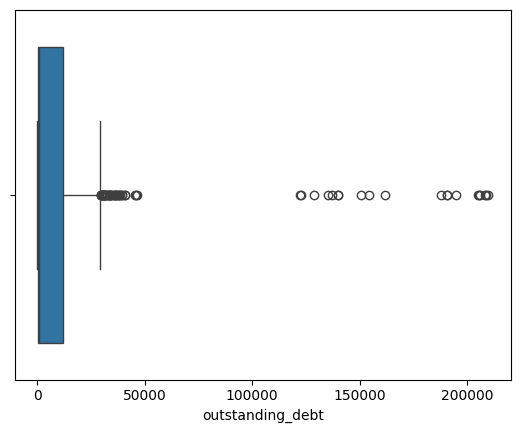

In [92]:
sns.boxplot(x=df_cs_clean_3.outstanding_debt)

Instead of using any statistical approach (such as standard deviation or IQR), here too we will use a business knowledge. We will mark any outstanding debt that is greater than credit limit as an outlier

In [93]:
df_cs_clean_3[df_cs_clean_3.outstanding_debt>df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750-799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700-749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750-799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300-449,500.0


We will replace these outliers with credit_limit. We can assume that there was some data processing error due to we got these high numbers and it is ok to replace them with a credit_limit

In [94]:
df_cs_clean_3.loc[df_cs_clean_3['outstanding_debt']>df_cs_clean_3['credit_limit'],'outstanding_debt']



1      161644.0
19     205014.0
25     190838.0
38     122758.0
93     137058.0
204    187849.0
271    154568.0
301    122402.0
330    208898.0
350    150860.0
446    206191.0
544    135112.0
636    140063.0
646    128818.0
698    190717.0
723    140008.0
725    205404.0
730    209901.0
766    195004.0
862    208406.0
Name: outstanding_debt, dtype: float64

In [95]:
df_cs_clean_3.loc[df_cs_clean_3['outstanding_debt']>df_cs_clean_3['credit_limit'],'outstanding_debt']=df_cs_clean_3['credit_limit']

In [96]:
df_cs_clean_3.loc[[301,730]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
301,302,722,0.608076,40000.0,4.0,40000.0,700-749,40000.0
730,731,626,0.762245,1500.0,2.0,1500.0,600-649,1500.0


In [97]:
df_cs_clean_3[df_cs_clean_3.outstanding_debt>df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


All outliers in column outstanding_debt are now GONE. Hurray 🙌🏼😀

In [98]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.00000,60000.000000


### 7.13_Data Exploration: Visualizing Correlation in Credit Score Table

Previously we see that Credit Score and Credit Limit has stronger Correlation

In [99]:
df_cust.head(2)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48


In [100]:
df_cs_clean_3.head(2)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0


Lets integrate these two above dataframes to do analysis Overall not only Customer Table

In [101]:
df_merged=df_cust.merge(df_cs_clean_3,on='cust_id',how='inner')
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [102]:
df_merged[['credit_score','credit_limit']].corr()

,credit_score,credit_limit
credit_score,1.000000,0.847952
credit_limit,0.847952,1.000000


In [103]:
numerical_columns=['credit_score','credit_utilisation','outstanding_debt','annual_income','age']
corr_matrix=df_merged[numerical_columns].corr()
corr_matrix

,credit_score,credit_utilisation,outstanding_debt,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.575751,0.438498
credit_utilisation,-0.070445,1.000000,0.192838,-0.086368,-0.019737
outstanding_debt,0.680654,0.192838,1.000000,0.555661,0.434403
annual_income,0.575751,-0.086368,0.555661,1.000000,0.601772
age,0.438498,-0.019737,0.434403,0.601772,1.000000


<Axes: >

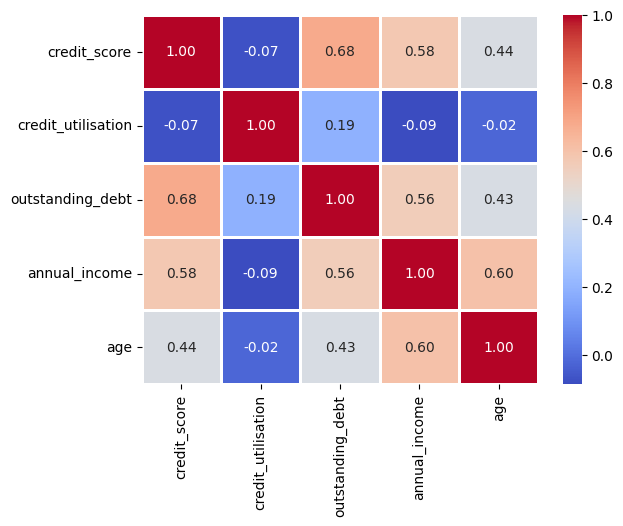

In [104]:
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.8)

You can see a high correlation between credit limit and credit score (~0.85)

Also credit limit and annual income has a high correlation.

This correlation table can be used for further analysis. It shows if one variable has relationship with the other variable

### 7.14_Exercise_Handle NULL Values in Transactions Table by Naima

In [105]:
df_trans.shape

(500000, 7)

In [106]:
df_trans.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

In [107]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


#### Credit card ka sab say pehlay platform check karlia

In [108]:
# 2️⃣ Filter Credit Card transactions
df_cc = df_trans[df_trans['payment_type'] == 'Credit Card']

In [109]:
cc_count_per_platform = df_cc.groupby('platform')['tran_id'].count().reset_index()
cc_count_per_platform.rename(columns={'tran_id': 'transaction_count'}, inplace=True)
print("Credit Card Transactions Count per Platform:")
print(cc_count_per_platform)


Credit Card Transactions Count per Platform:
   platform  transaction_count
0   Alibaba              19978
1    Amazon              44801
2      Cred               6841
3      Ebay               2610
4  Flipkart              33373
5    Meesho              20063
6   Shopify              10801


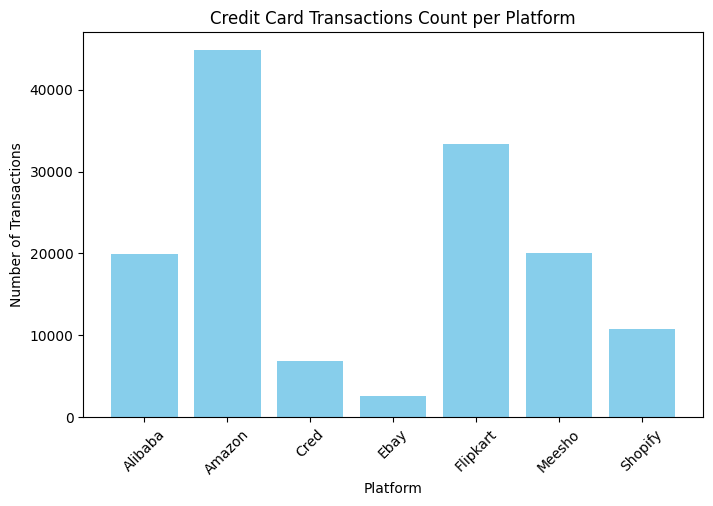

In [110]:
# 5️⃣ Optional: Plot transaction count per platform
plt.figure(figsize=(8,5))
plt.bar(cc_count_per_platform['platform'], cc_count_per_platform['transaction_count'], color='skyblue')
plt.title('Credit Card Transactions Count per Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

In [111]:
cc_transactions = df_trans[df_trans['payment_type'] == 'Credit Card']
cc_transactions.shape

(139778, 7)

#### Occupation wise platform check

In [112]:
# Merge df_trans with df_cust on 'cust_id'
df_merged_Tran = df_trans.merge(df_cust[['cust_id', 'occupation']], on='cust_id', how='left')
df_merged_Tran.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type,occupation
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe,Fullstack Developer
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card,Data Scientist
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe,Freelancer
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay,Fullstack Developer
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking,Freelancer


In [113]:
cc_merged = df_merged_Tran[df_merged_Tran['payment_type'] == 'Credit Card']
cc_merged.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type,occupation
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card,Data Scientist
6,7,388,2023-01-01,720,Alibaba,Electronics,Credit Card,Business Owner
11,12,487,2023-01-01,340,Shopify,Kitchen Appliances,Credit Card,Freelancer
12,13,440,2023-01-01,29,Amazon,Fashion & Apparel,Credit Card,Fullstack Developer
23,24,74,2023-01-01,818,Flipkart,Electronics,Credit Card,Business Owner


In [114]:
platform_by_occupation = cc_merged.groupby('occupation')['platform'].value_counts()
print(platform_by_occupation)


occupation           platform
Accountant           Amazon        829
                     Flipkart      640
                     Meesho        417
                     Alibaba       371
                     Shopify       193
                     Cred          138
                     Ebay           48
Artist               Amazon       1473
                     Flipkart     1076
                     Alibaba       685
                     Meesho        596
                     Shopify       369
                     Cred          234
                     Ebay           73
Business Owner       Amazon      15856
                     Flipkart    11967
                     Meesho       7304
                     Alibaba      7299
                     Shopify      3887
                     Cred         2508
                     Ebay          976
Consultant           Amazon       5340
                     Flipkart     4046
                     Meesho       2463
                     Alibaba      

#### Product wise platfoem check by Codebasicscourse

In [115]:
df_trans.platform.unique()

array(['Flipkart', 'Alibaba', 'Shopify', 'Amazon', 'Ebay', 'Meesho',
       'Cred', nan], dtype=object)

In [116]:
df_trans.platform.mode()

0    Amazon
Name: platform, dtype: object

In [117]:
df_trans.platform.value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='platform'>

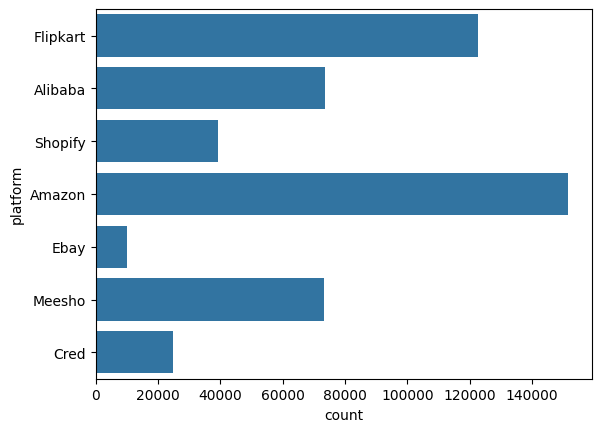

In [118]:
sns.countplot(y='platform',data=df_trans)

#### How to add product category in this bar chart

<Axes: xlabel='count', ylabel='product_category'>

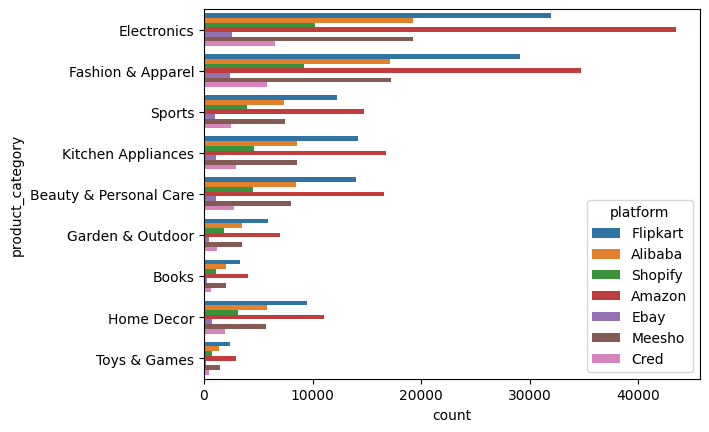

In [119]:
sns.countplot(y='product_category', hue='platform', data=df_trans)

##### In each category which line is dominating?
Answer is Amazon

#### 3no aspect say check krlia Amazon top pay h

In [120]:
df_trans.platform.mode()[0]

'Amazon'

In [121]:
df_trans.platform.fillna(df_trans.platform.mode()[0],inplace=True)

In [122]:
# # Fill all NULL platform values with 'Amazon'
# df_trans['platform'].fillna('Amazon', inplace=True)

In [123]:
df_trans.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

Once again we got rid of NULL values 🥳🎄🎈🎈

### 7.17_Treat Outliers using IQR (Transaction Amount)

#### Lets see if there is any outlier and invalid value

In [124]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


We can see transactions with 0 amount. These seem to be invalid 

Because my Business manager said transaction amount should not be 0

In [125]:
df_trans_zero=df_trans[df_trans.tran_amount==0]
df_trans_zero.shape

(4734, 7)

Letsdo the anaysis of this particular dataframe
One thing we notice that

In [126]:
df_trans_zero.platform.value_counts()

platform
Amazon    4734
Name: count, dtype: int64

In [127]:
df_trans_zero.product_category .value_counts()

product_category
Electronics    4734
Name: count, dtype: int64

In [128]:
df_trans_zero.payment_type.value_counts()

payment_type
Credit Card    4734
Name: count, dtype: int64

In [129]:
df_trans_zero[['platform','product_category','payment_type']].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

It appears that when platform=Amazon, product_category=Eletronics and payment_type=Credit Card, at that time we get all these zero transactions. 
We need to find other transactions in this group and find its median to replace these zero values. 
We are not using mean because we can see some outliers as well in this column

In [130]:
df_trans_1=df_trans[(df_trans.platform=='Amazon')& (df_trans.product_category=='Electronics')&(df_trans.payment_type=='Credit Card')]
df_trans_1.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card


In [131]:
df_trans[df_trans.tran_amount>0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking
...,...,...,...,...,...,...,...
499995,499996,791,2023-09-05,43,Amazon,Books,Phonepe
499996,499997,569,2023-09-05,53022,Meesho,Fashion & Apparel,Net Banking
499997,499998,57,2023-09-05,224,Amazon,Garden & Outdoor,Phonepe
499998,499999,629,2023-09-05,538,Flipkart,Home Decor,Gpay


In [132]:
median_to_replace=df_trans_1[df_trans_1.tran_amount>0].tran_amount.median()
median_to_replace

np.float64(554.0)

In [133]:
df_trans['tran_amount'].replace(0,median_to_replace,inplace=True)

In [134]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711635,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


<Axes: xlabel='tran_amount', ylabel='Count'>

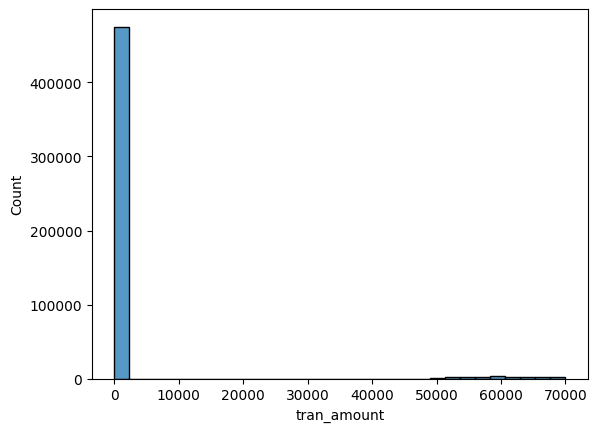

In [135]:
sns.histplot(df_trans['tran_amount'],bins=30)

Here you can see see it is rightky skewed.We can use IQR methods to remove outliers 


We can see outliers between 50000 to 700000


lets filter out data less than 10000

This give me subset of that

<Axes: ylabel='Count'>

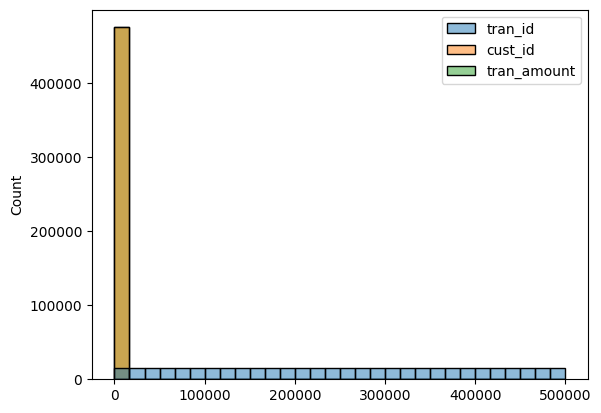

In [136]:
sns.histplot(df_trans[df_trans.tran_amount<10000],bins=30)

<Axes: xlabel='tran_amount', ylabel='Count'>

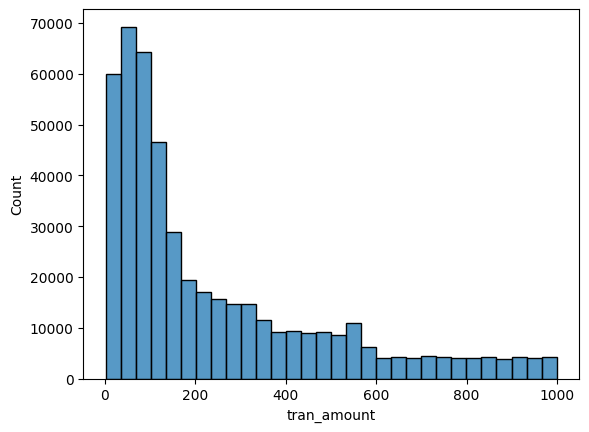

In [137]:
sns.histplot(df_trans[df_trans.tran_amount<10000].tran_amount,bins=30)

So its is peerfectly right skewed
 
Its better to use IQR Method

In [138]:
Q1,Q3=df_trans['tran_amount'].quantile([0.25,0.75])
IQR=Q3-Q1
lower=Q1 - 1.5 * IQR
upper=Q3 + 1.5 * IQR

In [139]:
lower,upper

(-454.5, 933.5)

Data Science is more about art than Science

When we discuss this with Business manager

This is fixed Criteria

We need to little flexible

So After discussion we have decided for 2 IQR

Manytime you discuss with Business manager and you might tweak this parameter

In Bloomberg Dhaval even use "7" z score instead of "3" Z score


In [140]:
Q1,Q3=df_trans['tran_amount'].quantile([0.25,0.75])
IQR=Q3-Q1
lower=Q1 - 2 * IQR
upper=Q3 + 2 * IQR
lower, upper

(-628.0, 1107.0)

We should not worry about lower limit here because transaction cannot be negative

In [141]:
df_tran_outliers=df_trans[(df_trans.tran_amount>=upper)]
df_tran_outliers.shape

(25000, 7)

Here we choose IQR to find outliers

lets say Business manager said any transaction above 10000 will considered outliers in this scenario we dont need to use IQR Method

So this is the thing..we need to keep in mind and be flexible.




Now how to treat this outliers?

1 way to do it to replace outliers with mean median of each product category because people might spend simililar amount on beauty products

In [142]:
df_trans_normal=df_trans[(df_trans.tran_amount<upper)]
df_trans_normal.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [143]:
tran_mean_per_category=df_trans_normal.groupby("product_category")['tran_amount'].mean()
tran_mean_per_category

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [144]:
df_trans.loc[df_tran_outliers.index] #df_trans me se wo rows nikaal do jinke index, df_tran_outliers ke index se match karte hain.”

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [145]:
df_trans.loc[df_tran_outliers.index,'tran_amount'] # gives only one column from those rows

26        61963
49        57869
94        52881
104       58574
113       51669
          ...  
499742    55131
499888    59679
499900    60184
499966    54678
499996    53022
Name: tran_amount, Length: 25000, dtype: int64

In [146]:
df_trans.loc[df_tran_outliers.index,'tran_amount']=df_tran_outliers['product_category']# df_trans me in dono rows ke tran_amount values ko 
                                                                                    # replace kar diya gaya with their corresponding product_category.

In [147]:
df_trans.loc[df_tran_outliers.index,'tran_amount']=df_tran_outliers['product_category'].map(tran_mean_per_category)

In [148]:
df_trans.loc[df_tran_outliers.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.333298,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.773288,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,64.553463,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,64.553463,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,64.553463,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,269.181631,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,269.181631,Meesho,Sports,Gpay


In [149]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


<Axes: xlabel='tran_amount', ylabel='Count'>

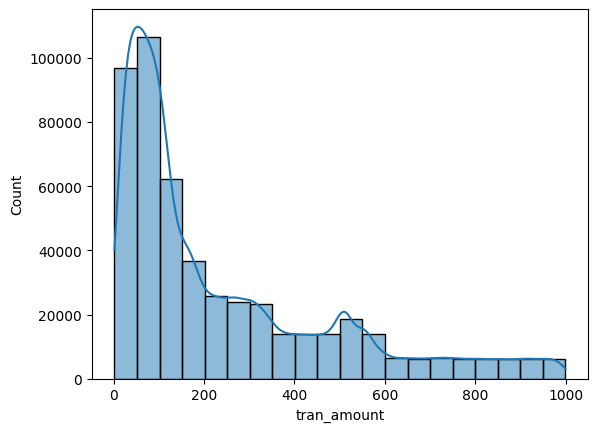

In [150]:
sns.histplot(df_trans.tran_amount, kde=True, bins=20)	

Now this looks much better

### 7.18 Data Visualization: Transactions Table

In [151]:
df_trans.head()


,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


The Distribution of payment type column

This means i want to know the count 

<Axes: xlabel='payment_type', ylabel='count'>

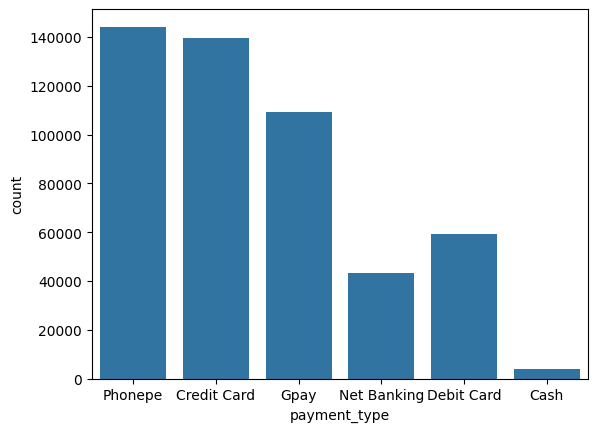

In [152]:
sns.countplot(x=df_trans.payment_type)

<Axes: xlabel='payment_type', ylabel='percent'>

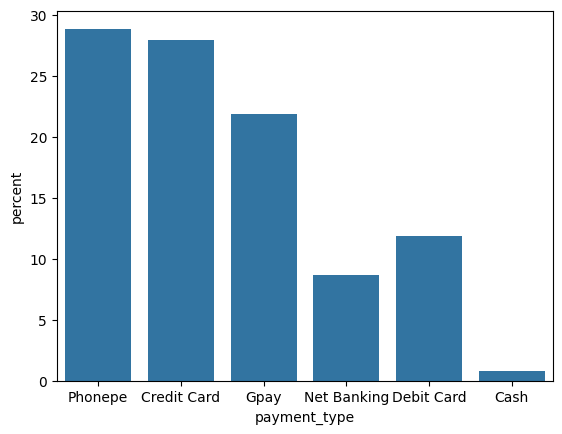

In [153]:
sns.countplot(x=df_trans.payment_type,stat='percent')

The usage of different paymment method per age group

We calculate the age group in customer table

For this we needto first merge Customer dataframe with Transaction dataframe

In [154]:
df_merged.head(3)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0


In [155]:
# df_merged_2=pd.merge(df_cust,df_trans,on="cust_id",how="inner")

Its better to merged df_merged with transaction table

In [156]:
df_merged_2=pd.merge(df_merged,df_trans,on="cust_id",how="inner")
df_merged_2.head(3)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48,749,...,0.0,40000.0,700-749,40000.0,1283,2023-01-01,30,Shopify,Fashion & Apparel,Net Banking
1,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48,749,...,0.0,40000.0,700-749,40000.0,1382,2023-01-01,96,Amazon,Sports,Debit Card
2,1,Manya Acharya,Female,46,City,Business Owner,358211.0,Married,26-48,749,...,0.0,40000.0,700-749,40000.0,1521,2023-01-01,86,Meesho,Garden & Outdoor,Gpay


In [157]:
df_merged_2.shape

(500000, 22)

<Axes: xlabel='age_group', ylabel='count'>

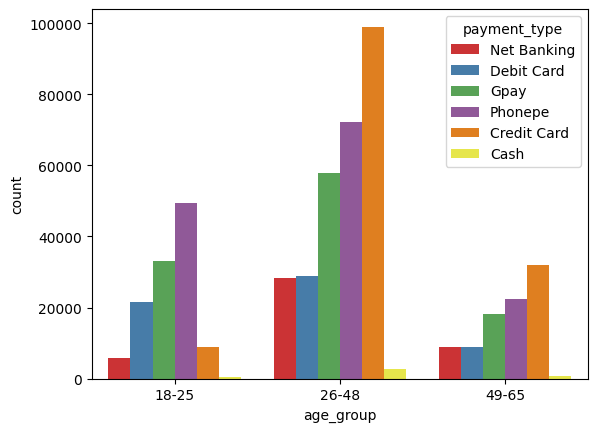

In [158]:
sns.countplot(x='age_group',hue='payment_type',data=df_merged_2,palette='Set1')

less number of people in 18_25 use Credit card


But High number of people in 26_48 use Credit 


And all age group use very less number of cash payments

Further Formatting

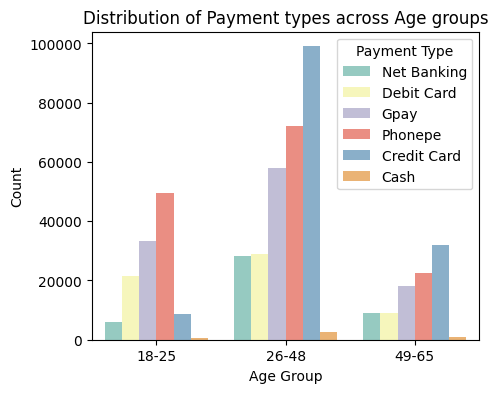

In [159]:
plt.figure(figsize=(5, 4))
sns.countplot(x='age_group', hue='payment_type', data=df_merged_2, palette='Set3')
plt.title('Distribution of Payment types across Age groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Payment Type', loc='upper right')

plt.show()

if you want to know platform distribution

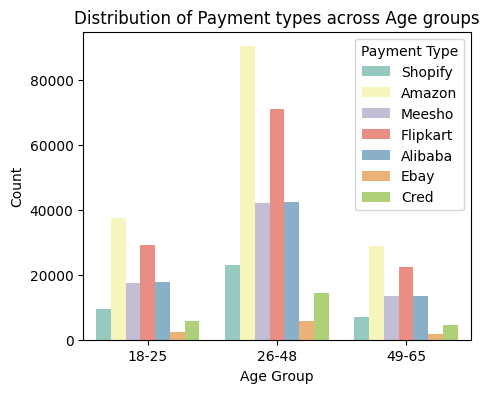

In [160]:
plt.figure(figsize=(5, 4))
sns.countplot(x='age_group', hue='platform', data=df_merged_2, palette='Set3')
plt.title('Distribution of Payment types across Age groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Payment Type', loc='upper right')

plt.show()

I Want to plot these two graph side by side

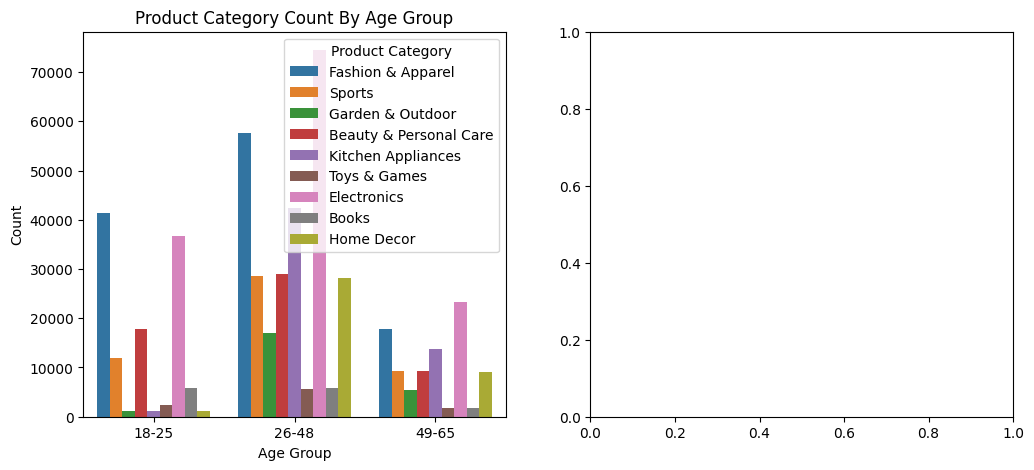

In [164]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='age_group', hue="product_category", data=df_merged_2, ax=ax1)
ax1.set_title("Product Category Count By Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax1.legend(title="Product Category", loc='upper right')


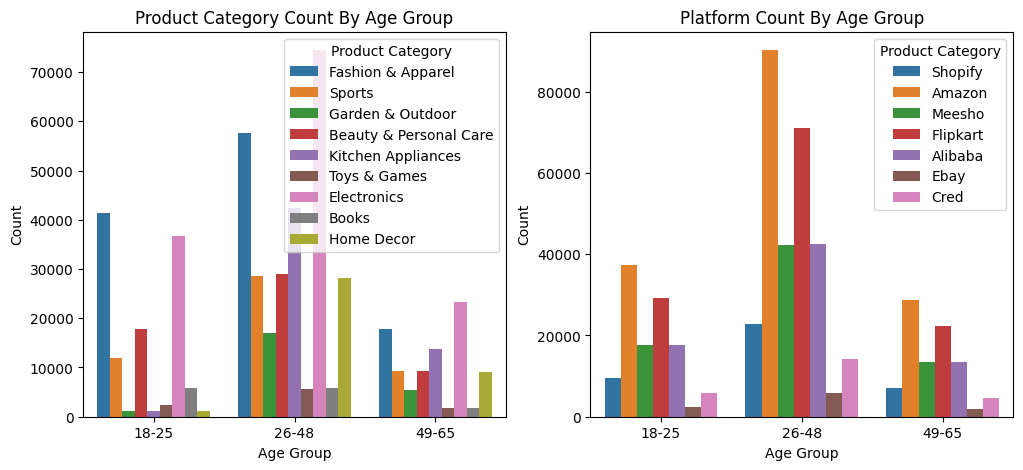

In [165]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='age_group', hue="product_category", data=df_merged_2, ax=ax1)
ax1.set_title("Product Category Count By Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count")
ax1.legend(title="Product Category", loc='upper right')

sns.countplot(x='age_group', hue="platform", data=df_merged_2, ax=ax2)
ax2.set_title("Platform Count By Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Count")
ax2.legend(title="Product Category", loc='upper right')

plt.show()

### Observations:

1. Top 3 purchasing categories of customers in age group (18 -25) : Electronics, Fashion & Apparel, Beauty & personal care
1. Top platforms : Amazon, Flipkart, Alibaba

Further Visualizations

Yeh Dhaval nay direct paste kia h

### Data Visualization: Average Transaction Amount

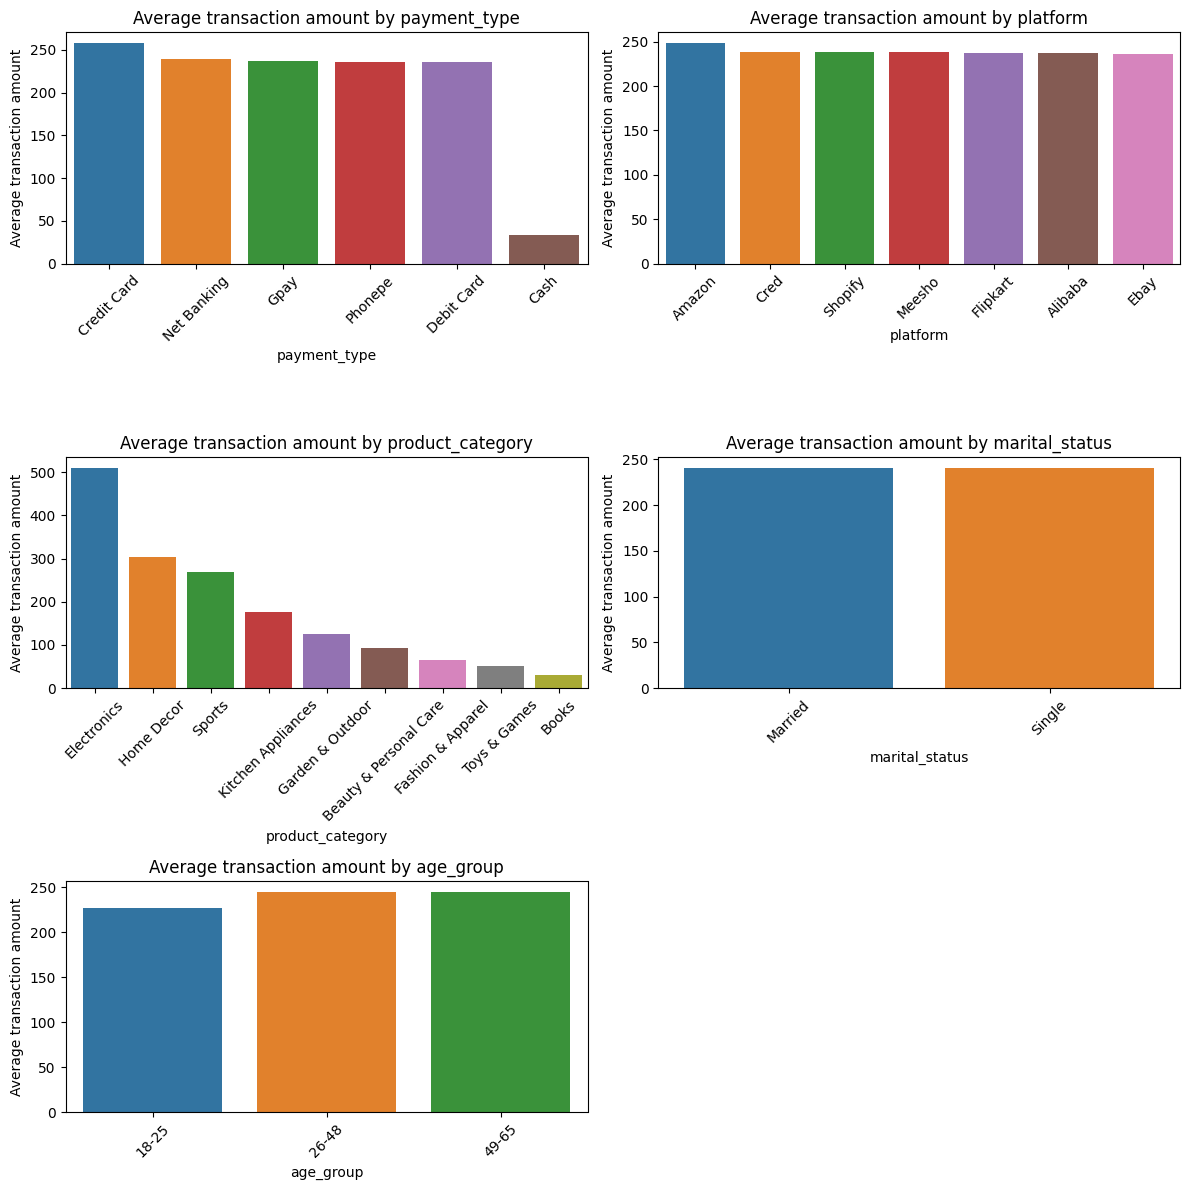

In [170]:
# List of categorical columns
cat_cols = ['payment_type', 'platform', 'product_category', 'marital_status', 'age_group']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_tran_amount_by_category = df_merged_2.groupby(cat_col)['tran_amount'].mean().reset_index()
    
    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_tran_amount_by_category.sort_values(by='tran_amount', ascending=False)
    
    sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average transaction amount by {cat_col}')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average transaction amount')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

Credit Card Average transaction amount is higher

Cash Average transaction amount is lower

Higher Transaction amountfor Electronics is higher